In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pymoo.indicators.hv import Hypervolume
import score.envs as envs
import itertools

2024-10-18 15:03:28.981439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-18 15:03:28.998658: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-18 15:03:29.003936: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-18 15:03:29.016471: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-18 15:03:30.006186: W tensorflow/compiler/tf2

In [2]:
plt.rcParams['font.family'] = 'serif'

In [3]:
# # env_id = "SCORE-MO-CEBAF-8D-VEC-TF"
# # env_id = "SCORE-MO-CEBAF-16D-VEC-TF"
# env_id = "SCORE-MO-CEBAF-16D-VEC-TF"
# # env_id = "SCORE-MO-CEBAF-N-VEC-TF-v0"

# env = envs.make(env_id)
# ref = [env.linac.max_allowed_heat, env.linac.max_allowed_trip]
# if "-8D-" in env_id:
#     ideal = [20.9, 0.015]
# if "-16D-" in env_id:
#     ideal = [85., 0.0]
# if "-32D-" in env_id:
#     ideal = [260., 0.0]
# elif "-N-" in env_id:
#     ideal = [2380.0, 1.0]
# energy_bound = [env.min_energy, env.max_energy]

env_ids = ["SCORE-MO-CEBAF-8D-VEC-TF", 
        "SCORE-MO-CEBAF-16D-VEC-TF",
        "SCORE-MO-CEBAF-32D-VEC-TF",
        "SCORE-MO-CEBAF-N-VEC-TF-v0"]

envs = [envs.make(env_id) for env_id in env_ids]
refs = [[env.linac.max_allowed_heat, env.linac.max_allowed_trip] for env in envs]

ideals = [[20.9, 0.015],
          [88., 0.015],
          [262., 0.010],
          [2380.0, 1.0]]

energy_bounds = [[env.min_energy, env.max_energy] for env in envs]

Attempting to load score.envs with mo_cebaf_env
####################################
Using action mode:  direct
####################################


2024-10-18 15:03:31.843651: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13762 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:2d:00.0, compute capability: 7.5
2024-10-18 15:03:31.845770: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13762 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:30:00.0, compute capability: 7.5


Env Name:  1l10_test8
Cavity Ids:  ['1L10-1' '1L10-2' '1L10-3' '1L10-4' '1L10-5' '1L10-6' '1L10-7' '1L10-8']
Lengths:  tf.Tensor([0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5], shape=(8,), dtype=float32)
types:  ['C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25' 'C25']
max_gset_to_use:  [5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]
min grad:  tf.Tensor([3. 3. 3. 3. 3. 3. 3. 3.], shape=(8,), dtype=float32)
Q0s:  tf.Tensor([5.21e+09 5.00e+09 6.82e+09 4.77e+09 5.31e+09 5.32e+09 2.60e+09 3.92e+09], shape=(8,), dtype=float32)
Trip slopes:  tf.Tensor([1.301 1.485 1.942 1.911 0.487 1.519 2.788 1.339], shape=(8,), dtype=float32)
Trip Offset:  tf.Tensor([9.328 8.724 8.845 5.679 9.528 8.108 6.389 7.684], shape=(8,), dtype=float32)
Initial gradients:  tf.Tensor([[5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]], shape=(1, 8), dtype=float32)
Requred energy mean:  20.08   with allowed margin:  0.4
Using min, max energy boundaries as:  tf.Tensor(12.0, shape=(), dtype=float32) tf.Tensor(28.175, shape=(), dtype=float32)
Min and Max 

In [4]:
def calculate_hv(heat, trip, ref, ideal):
    metric = Hypervolume(ref_point= ref,
                         norm_ref_point=False,
                         zero_to_one=False,
                         ideal=ideal,
                         nadir=ref)
    max_vol = (ref[0] - ideal[0]) * (ref[1] - ideal[1])
    good_indices = np.where((heat <= ref[0]) & (trip <= ref[1]))[0]
    
    # If no points are below reference, return hypervolume as 0.
    if good_indices.shape[0] <= 0:
        return 0.
    heat, trip = heat[good_indices], trip[good_indices]
    results = np.stack([heat, trip], axis=1)
    
    return np.round(metric.do(results)*100/max_vol, 3)
    

In [5]:
def read_results(path, energy_min, energy_max, ref, ideal):
    heat, trip, time, step_time = [], [], [], []
    alphas = []
    hv_list = []
    files = sorted(os.listdir(path))
    counter = 0
    for file in files:
        if file[-4:] != ".pkl":
            continue
        
        result_dict = np.load(os.path.join(path, file), allow_pickle=True)
        h = np.array(result_dict["heat"])
        t = np.array(result_dict["trip"])
        if "DDRL" in path or "MOTD3" in path:
            a = np.array(result_dict["alpha"])
        else:
            a = []
        if "MOBO" in path:
            energy = np.array(result_dict["energy"])
            good_indices = np.where((energy <= energy_max) & (energy >= energy_min))[0]
            h = h[good_indices]
            t = t[good_indices]
        heat.append(h)
        trip.append(t)
        alphas.append(a)
        step_time.append(result_dict["step_time"])
        time.append(result_dict["t_elapsed"])
        hv_list.append(calculate_hv(h, t, ref, ideal))
        counter += 1
        if "MOTD3" in path:
            if counter >= 1000:
                break
    return heat, trip, np.array(time), np.array(step_time), hv_list, alphas

In [6]:
path_list = {}
env_list = ["8D", "16D", "32D", "North Linac"]
algo_list = ["MOBO", "MOGA", "DDRL", "MOTD3"]
root_dir = "/work/data_science/kishan_RL_results/"
for e in env_list:
    path_list[e] = {}
    for a in algo_list:
        if e == "8D":
            path_list[e][a] = os.path.join(root_dir, "results/MOO_paper_study_v2/"+str(a))
        elif e == "16D":
            path_list[e][a] = os.path.join(root_dir, "results/MOO_paper_study_16D/"+str(a))
        elif e == "32D":
            path_list[e][a] = os.path.join(root_dir, "results/MOO_paper_study_32D/"+str(a))
        else:
            path_list[e][a] = os.path.join(root_dir, "results/MOO_paper_study_v2/"+str(a)+"_North")
            if a == "DDRL":
                path_list[e][a] = os.path.join(root_dir, "results/MOO_paper_study_v2/"+str(a)+"_North_lose")
                

In [7]:
path_list

{'8D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOTD3'},
 '16D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOTD3'},
 '32D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_pape

In [8]:
# path_list_8d = ["../results/MOO_paper_study_v2/MOBO/",
#                 "../results/MOO_paper_study_v2/MOGA/",
#                 "../results/MOO_paper_study_v2/DDRL/",
#                 "../results/MOO_paper_study_v2/MOTD3_v2/"]

# path_list_16d = ["../results/MOO_paper_study_16D/MOBO/",
#                  "../results/MOO_paper_study_16D/MOGA/",
#                  "../results/MOO_paper_study_16D/DDRL/",
#                  "../results/MOO_paper_study_16D/MOTD3/"]

# path_list_32d = ["../results/MOO_paper_study_32D/MOBO/",
#                  "../results/MOO_paper_study_32D/MOGA/",
#                  "../results/MOO_paper_study_32D/DDRL/",
#                  "../results/MOO_paper_study_32D/MOTD3/"]

# path_list_north = ["../results/MOO_paper_study_v2/MOBO_North/",
#                    "../results/MOO_paper_study_v2/MOGA_North/",
#                    "../results/MOO_paper_study_v2/DDRL_North/",
#                    "../results/MOO_paper_study_v2/MOTD3_North/"]

label_list = ["MOBO", "MOGA", "DDRL", "MOTD3"]

In [9]:
path_list

{'8D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOTD3'},
 '16D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOTD3'},
 '32D': {'MOBO': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOBO',
  'MOGA': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA',
  'DDRL': '/work/data_science/kishan_RL_results/results/MOO_paper_study_32D/DDRL',
  'MOTD3': '/work/data_science/kishan_RL_results/results/MOO_pape

In [10]:
def read(path, energy_bound, ref, ideal):
    
    heat_list = []
    trip_list = []
    time_list = []
    alpha_list = []
    hv_list = []
    for i in range(1, 16):
        full_path = os.path.join(path, "trial_"+str(i))
        heat, trip, time, step_time, hv, alphas = read_results(full_path, energy_bound[0], energy_bound[1], ref, ideal)
        heat_list.append(heat)
        trip_list.append(trip)
        time_list.append(time)
        hv_list.append(hv)
        alpha_list.append(alphas)
    return heat_list, trip_list, time_list, hv_list, alpha_list

In [11]:
results = {}  # Ordered as 8D, 16D, 32D, 200D
for i, e in enumerate(env_list):
    results[e] = {}
    for a in path_list[e]:
        h, t, time, hv, alpha = read(path_list[e][a], energy_bounds[i], refs[i], ideals[i])
        if a == "MOBO":
            max_len = max([len(h) for h in hv])
            time2 = []
            hv2 = []
            for j in range(len(hv)):
                l = len(hv[j])
                length_diff = max_len - l
                hv2.append(np.concatenate([hv[j], np.array([hv[j][-1]]*length_diff)]))
                time2.append(np.concatenate([time[j], np.array([time[j][-1]]*length_diff)], axis=0))
            
            results[e][a] = [h, t, time2, hv2, alpha, time, hv]
        else:
            results[e][a] = [h, t, time, hv, alpha]
        print("Read: ", path_list[e][a])

Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOBO
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOGA
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/DDRL
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOTD3
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOBO
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOGA
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/DDRL
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_16D/MOTD3
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOBO
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOGA
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/DDRL
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_32D/MOTD3
Read:  /work/data_science/kishan_RL_results/results/MOO_paper_study_v2/MOBO_N

In [12]:
# mobo_hv_padded = np.array(list(zip(*itertools.zip_longest(*mobo_hv_list, fillvalue=0))))
# mobo_time_padded = np.array(list(zip(*itertools.zip_longest(*mobo_time_list, fillvalue=0))))

In [13]:
for hv in results["North Linac"]["MOBO"][3]:
    print(len(hv))

1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000
1000


In [14]:
colors = ["#0D59F2", "#F2A60D", "#55AA8F", "#AA5570"]
def get_hypervolume_comparison_v2(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None, xscale=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_median = np.median(hv_list[i], axis=0)
        hv_upper = np.quantile(hv_list[i], q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_list[i], q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    if xscale is not None:
        plt.xscale(xscale)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()


def get_hypervolume_comparison_v3(hv_list, time_list, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None, xscale=None):
    for i in range(len(hv_list)):
        print(label_list[i], " Max HV: ", np.max(hv_list[i]))
        # hv_mean = np.mean(hv_list[i], axis=0)
        # hv_std = np.std(hv_list[i], axis=0)
        # time_mean = np.mean(time_list[i], axis=0) / 60.
        # time_std = np.std(time_list[i], axis=0) / 60.
        hv_cummax_list = np.array([np.maximum.accumulate(X) for X in hv_list[i]])
        print(hv_cummax_list.shape)
        hv_median = np.median(hv_cummax_list, axis=0)
        hv_upper = np.quantile(hv_cummax_list, q=upper_q, axis=0) - hv_median
        hv_lower = hv_median - np.quantile(hv_cummax_list, q=lower_q, axis=0)
        time = np.array(time_list[i]) / 60.
        time_median = np.median(time, axis=0)
        time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
        time_lower = time_median - np.quantile(time, q=lower_q, axis=0)

        if x_axis == "time":
            x = time_median
            xerr = np.vstack([time_lower, time_upper])
            xlabel = "Time (min)"
        else:
            x = np.arange(len(time_median))
            if "MOBO" not in label_list[i]:
                x = x*100
            xerr = None
            xlabel = "Steps"
        if plot_type == "area":
            plt.fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=label_list[i], color=colors[i], alpha=0.65)
            # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        else:
            plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Hypervolume (Normalized %)", fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(fontsize=14)
    if xscale is not None:
        plt.xscale(xscale)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.show()

In [15]:
def get_hypervolume_comparison_v4(results, label_list, colors, x_axis="time", upper_q=0.75, lower_q=0.25, plot_type="area", xlim=None, ylim=None, xscale=None, saveloc=None):
    # Create a figure and a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    counter = 0
    for problem_name in env_list:
        for i, algo in enumerate(algo_list):
            hv_list = results[problem_name][algo][3]
            hv_cummax_list = np.array([np.maximum.accumulate(X) for X in hv_list])
            # print(hv_cummax_list.shape)
            hv_median = np.median(hv_cummax_list, axis=0)
            hv_upper = np.quantile(hv_cummax_list, q=upper_q, axis=0) - hv_median
            hv_lower = hv_median - np.quantile(hv_cummax_list, q=lower_q, axis=0)
            time_list = results[problem_name][algo][2]
            time = np.array(time_list) / 60.
            time_median = np.median(time, axis=0)
            time_upper = np.quantile(time, q=upper_q, axis=0) - time_median
            time_lower = time_median - np.quantile(time, q=lower_q, axis=0)
    
            if x_axis == "time":
                x = time_median
                xerr = np.vstack([time_lower, time_upper])
                xlabel = "Time (min)"
                if "MOTD3" in algo:
                    x = x[2:]
                    xerr = xerr[2:]
                    hv_median = hv_median[2:]
                    hv_upper, hv_lower = hv_upper[2:], hv_lower[2:]
            else:
                x = np.arange(len(time_median))
                if "MOBO" not in algo:
                    x = x*100
                xerr = None
                xlabel = "Steps"
            if plot_type == "area":
                axs[counter//2, counter%2].fill_between(x, y1=hv_median-hv_lower, y2=hv_median+hv_upper, label=str(algo), color=colors[i], alpha=0.65)
                # plt.errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=label_list[i], fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
            else:
                axs[counter//2, counter%2].errorbar(x, hv_median, yerr=np.vstack([hv_lower, hv_upper]), xerr=xerr, label=str(algo), fmt='o', color=colors[i], markersize=5, capsize=3, elinewidth=2, alpha=0.65)
        
        axs[counter//2, counter%2].set_title(problem_name, fontsize=18)
        axs[counter//2, counter%2].grid(color="gray", alpha=0.5, ls="--")
    
        # Remove box around the plot
        axs[counter//2, counter%2].spines['top'].set_visible(False)
        axs[counter//2, counter%2].spines['right'].set_visible(False)
        plt.legend(fontsize=15)
        axs[counter//2, counter%2].tick_params(axis='both', which='major', labelsize=14)
        if xscale is not None:
            axs[counter//2, counter%2].set_xscale(xscale)
    
        counter += 1
    if x_axis == "time":
        xlabel = "Time (min)"
    else:
        xlabel = "Steps"
    fig.supxlabel(xlabel, fontsize=18)
    fig.supylabel('Hypervolume Normalized (%)', fontsize=18)
    
    # Adjust layout
    plt.tight_layout()
    if saveloc is not None:
        plt.savefig(saveloc, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552416/2792640611.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


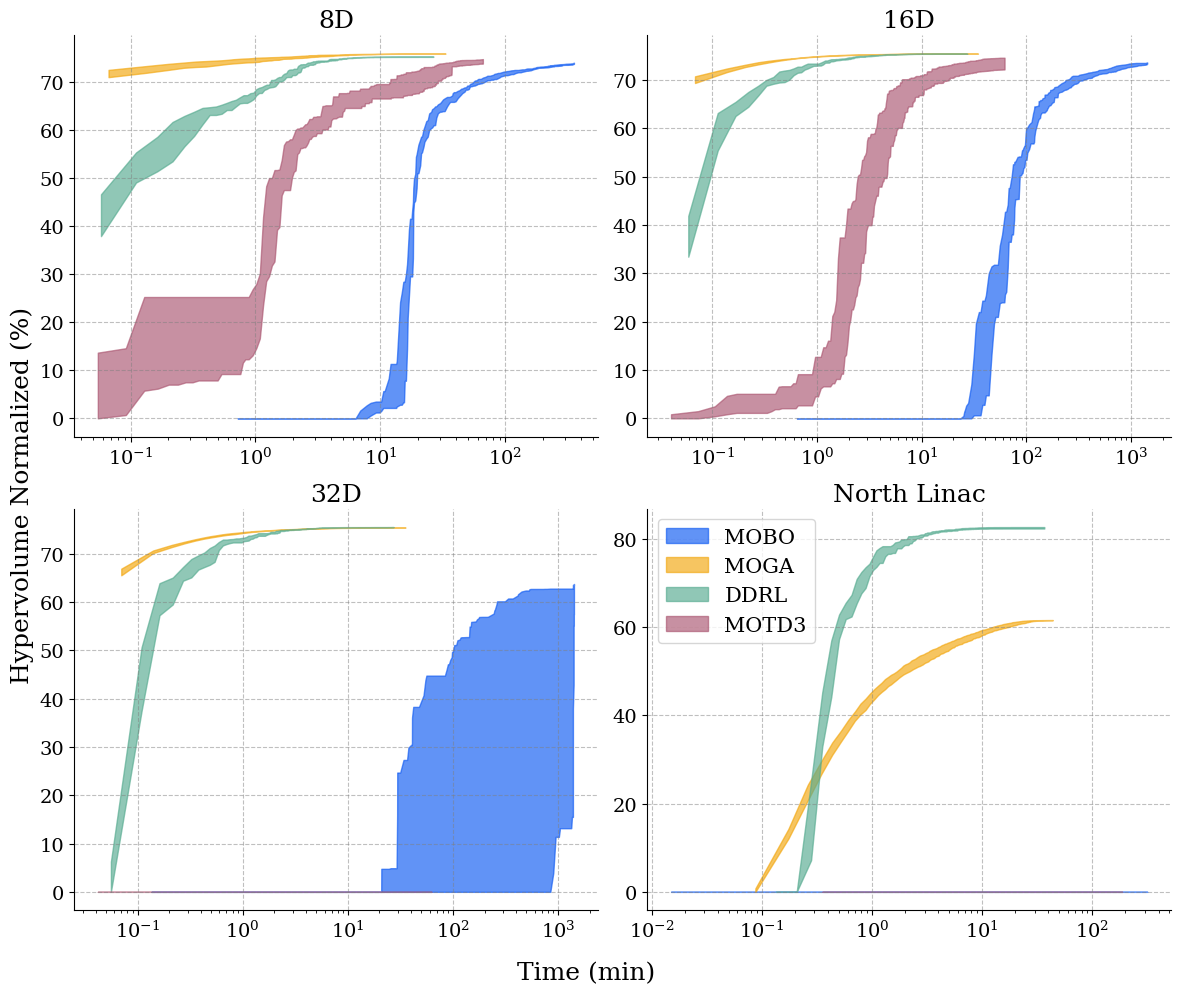

In [16]:
get_hypervolume_comparison_v4(results, algo_list, colors, xscale="log", saveloc="HV_Comparison_All_log_time.pdf", x_axis="time")

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552416/2792640611.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


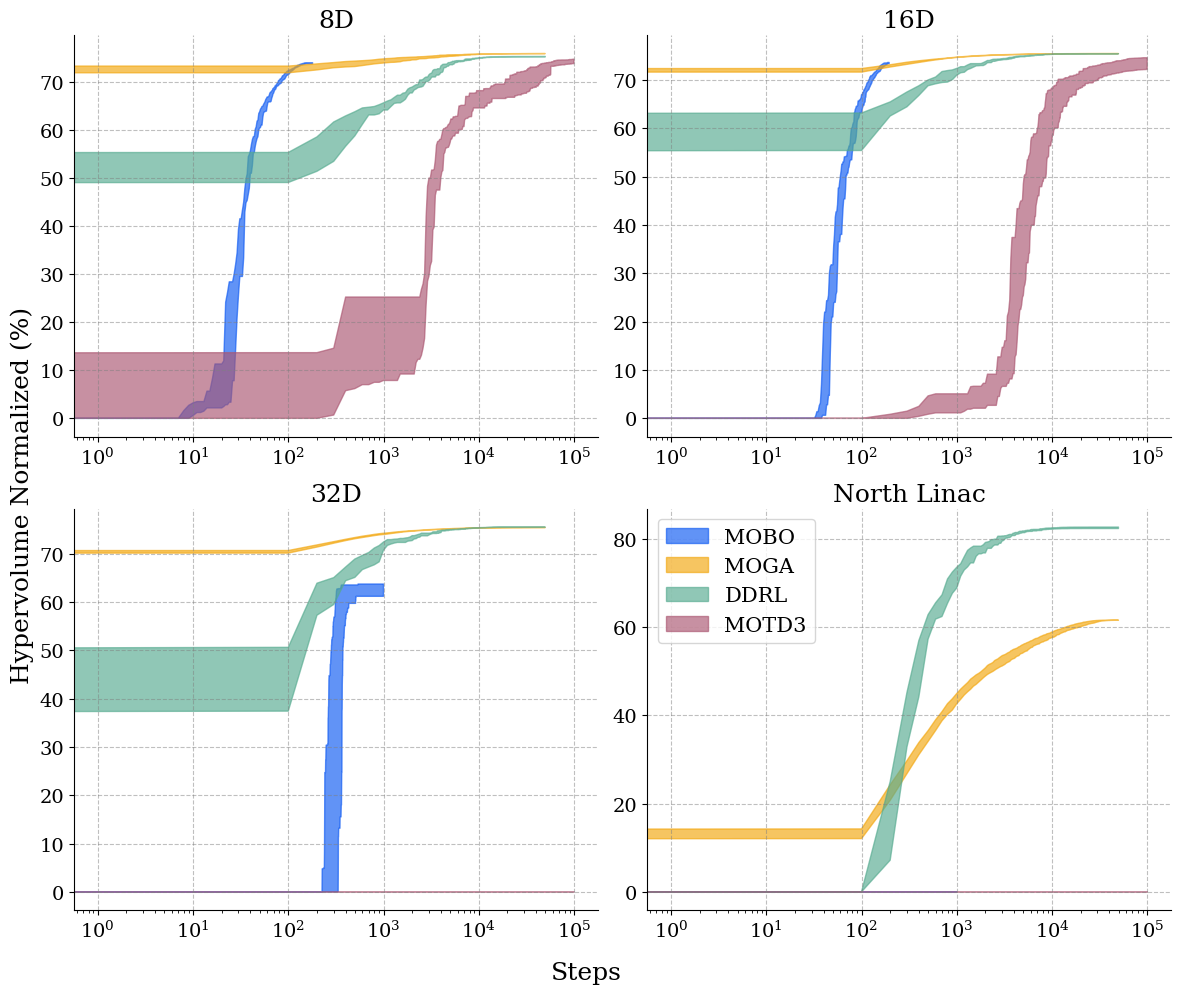

In [17]:
get_hypervolume_comparison_v4(results, algo_list, colors, xscale="log", saveloc="HV_Comparison_All_log_step.pdf", x_axis="Step")

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552416/2792640611.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


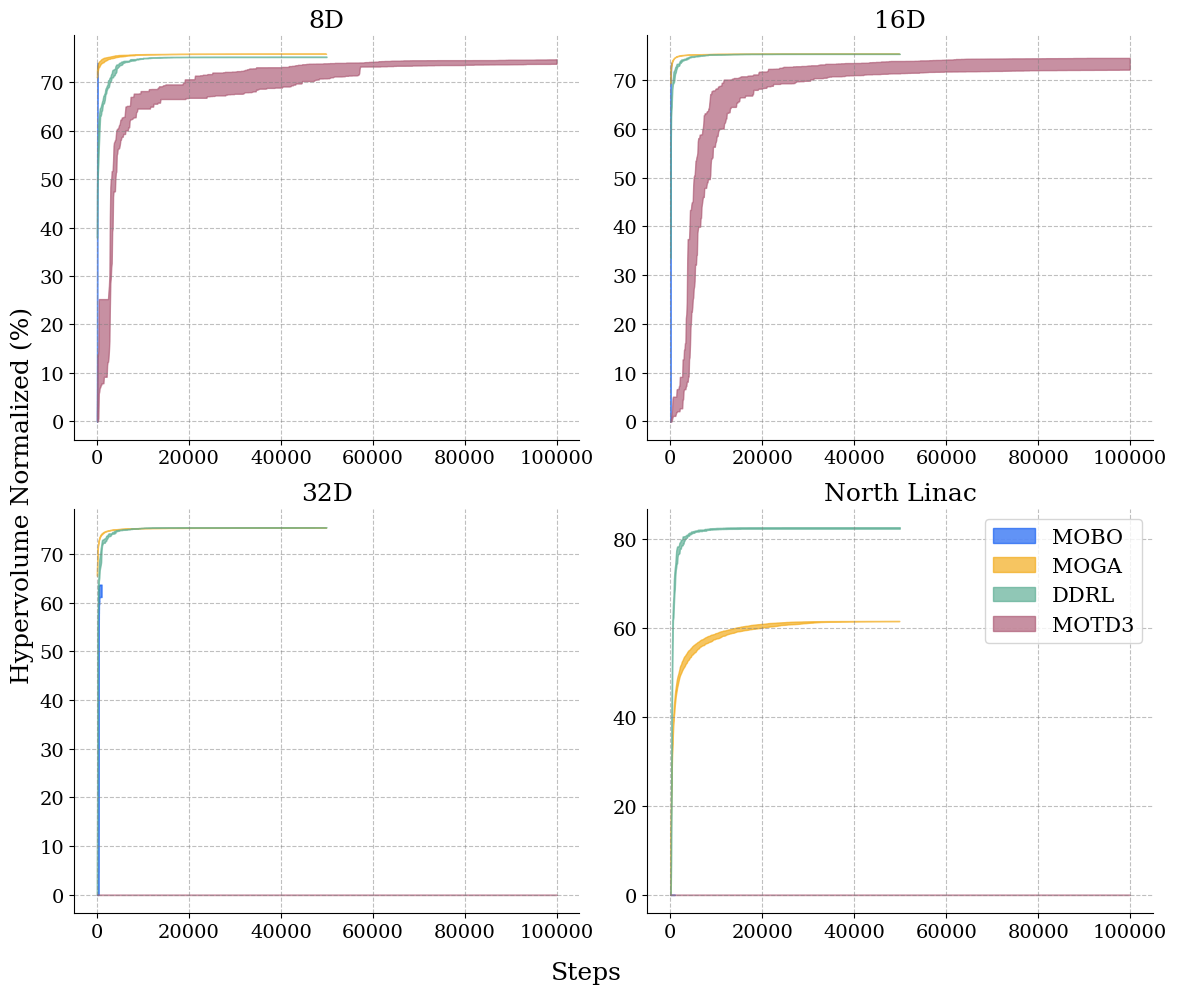

In [18]:
get_hypervolume_comparison_v4(results, algo_list, colors, saveloc="HV_Comparison_All_step.pdf", x_axis="Step")

/scratch/slurm/31353920/.cache/tmp/ipykernel_1552416/2792640611.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


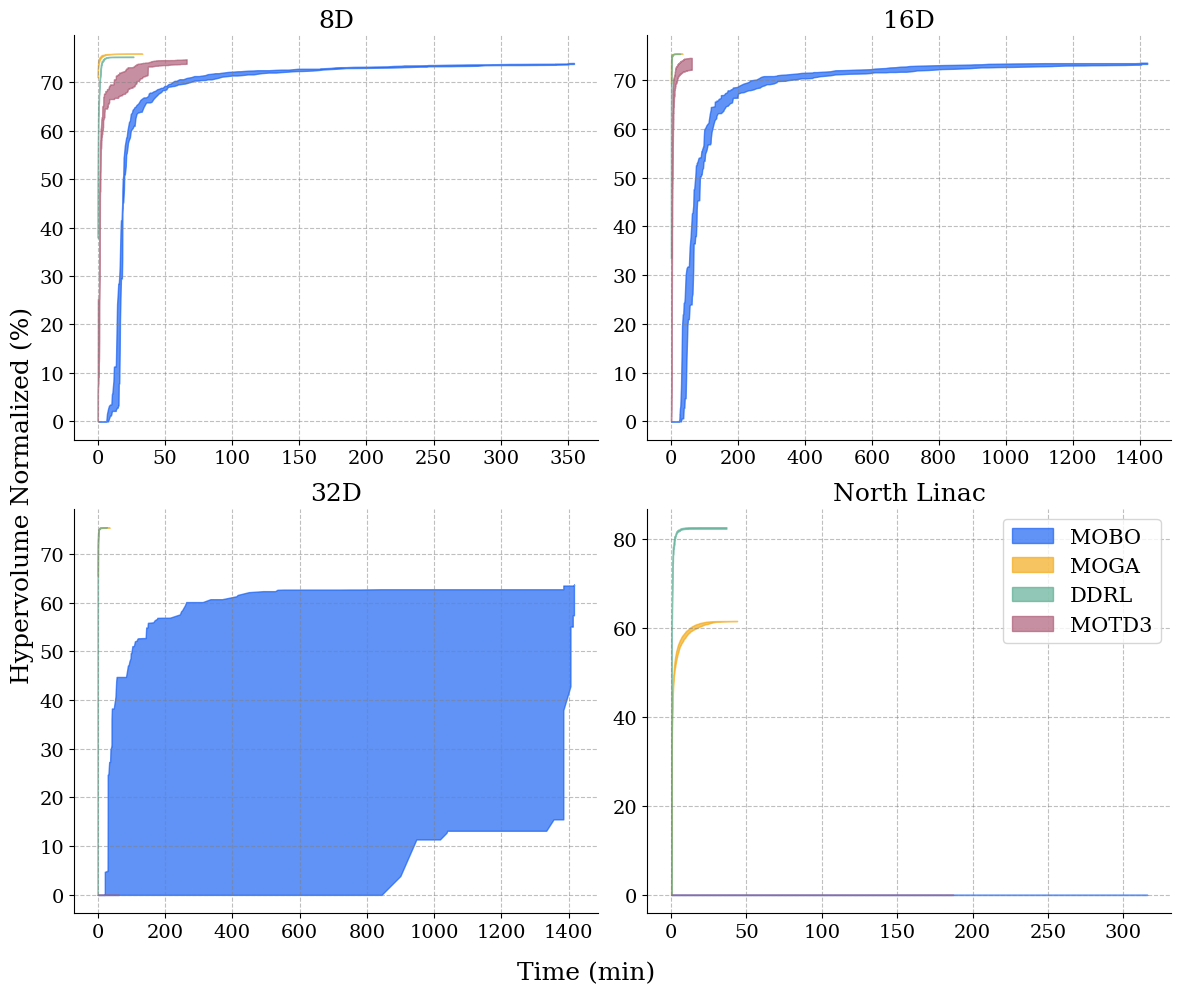

In [19]:
get_hypervolume_comparison_v4(results, algo_list, colors, saveloc="HV_Comparison_All_time.pdf")

In [20]:
one_sigma_bound = [0.186, 0.814]
two_sigma_bound = [0.023, 0.977]
colors = ["#0D59F2", "#F2A60D", "#55AA8F", "#AA5570"]

MOBO  Max HV:  0.0
(15, 1000)
MOGA  Max HV:  61.608
(15, 499)
DDRL  Max HV:  82.701
(15, 500)
MOTD3  Max HV:  0.0
(15, 1000)


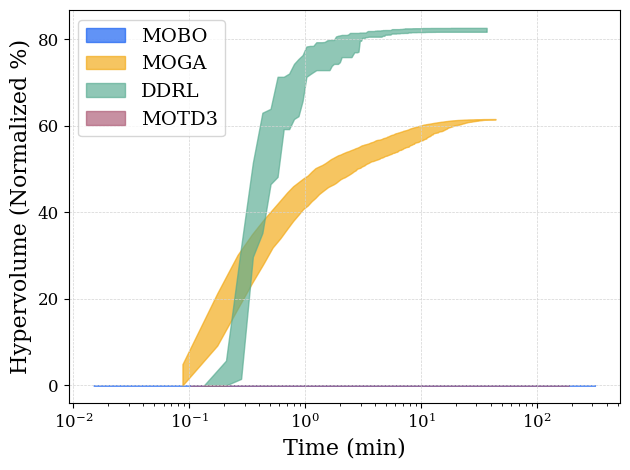

MOBO  Max HV:  0.0
(15, 1000)
MOGA  Max HV:  61.608
(15, 499)
DDRL  Max HV:  82.701
(15, 500)
MOTD3  Max HV:  0.0
(15, 1000)


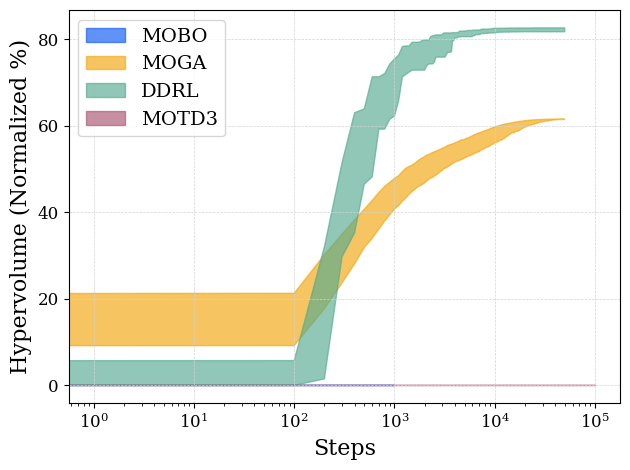

In [21]:
e = "North Linac"
prep_results = []
prep_time = []
for i, a in enumerate(algo_list):
    prep_results.append(results[e][a][3])
    prep_time.append(results[e][a][2])
xscale = "log"
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)

MOBO  Max HV:  74.36
(15, 181)
MOGA  Max HV:  75.86
(15, 499)
DDRL  Max HV:  75.27
(15, 500)
MOTD3  Max HV:  74.979
(15, 1000)


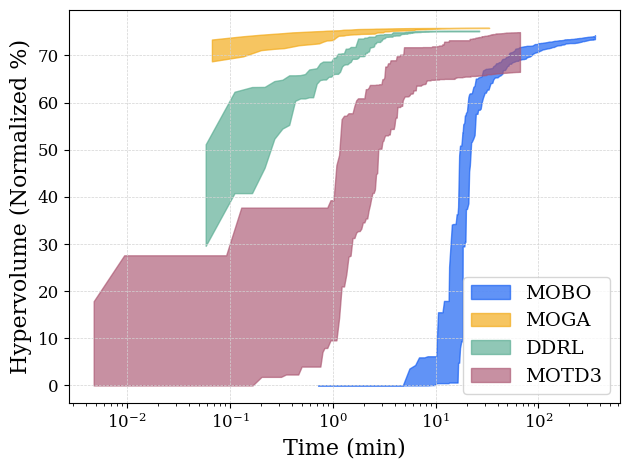

MOBO  Max HV:  74.36
(15, 181)
MOGA  Max HV:  75.86
(15, 499)
DDRL  Max HV:  75.27
(15, 500)
MOTD3  Max HV:  74.979
(15, 1000)


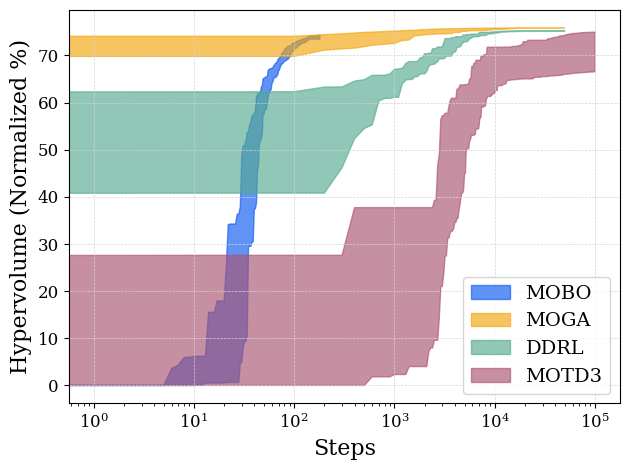

In [22]:
e = "8D"
prep_results = []
prep_time = []
for i, a in enumerate(algo_list):
    prep_results.append(results[e][a][3])
    prep_time.append(results[e][a][2])
xscale = "log"
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)

MOBO  Max HV:  73.985
(15, 196)
MOGA  Max HV:  75.455
(15, 499)
DDRL  Max HV:  75.422
(15, 500)
MOTD3  Max HV:  74.826
(15, 1000)


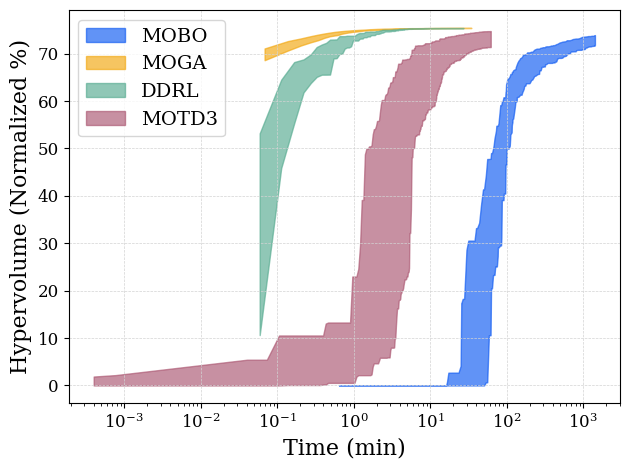

MOBO  Max HV:  73.985
(15, 196)
MOGA  Max HV:  75.455
(15, 499)
DDRL  Max HV:  75.422
(15, 500)
MOTD3  Max HV:  74.826
(15, 1000)


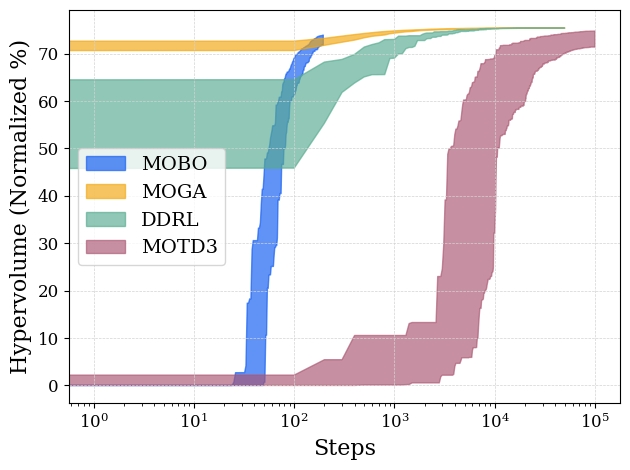

In [23]:
e = "16D"
prep_results = []
prep_time = []
for i, a in enumerate(algo_list):
    prep_results.append(results[e][a][3])
    prep_time.append(results[e][a][2])
xscale = "log"
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)

MOBO  Max HV:  66.33
(15, 1000)
MOGA  Max HV:  75.428
(15, 499)
DDRL  Max HV:  75.523
(15, 500)
MOTD3  Max HV:  0.0
(15, 1000)


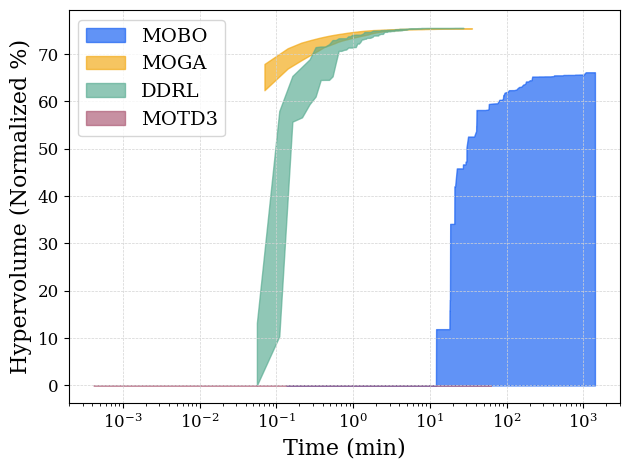

MOBO  Max HV:  66.33
(15, 1000)
MOGA  Max HV:  75.428
(15, 499)
DDRL  Max HV:  75.523
(15, 500)
MOTD3  Max HV:  0.0
(15, 1000)


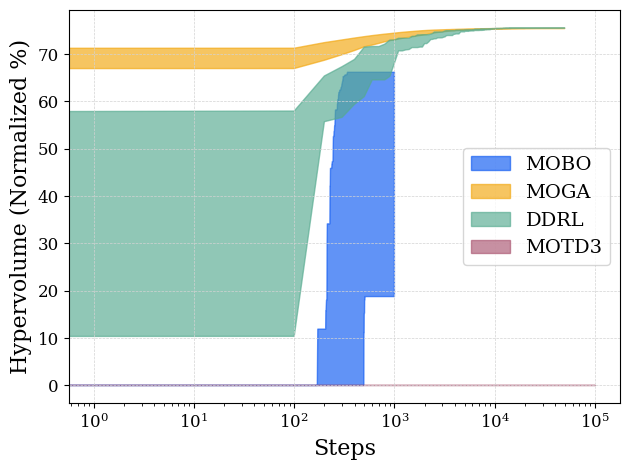

In [24]:
e = "32D"
prep_results = []
prep_time = []
for i, a in enumerate(algo_list):
    prep_results.append(results[e][a][3])
    prep_time.append(results[e][a][2])
xscale = "log"
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
# get_hypervolume_comparison_v2([mobo_hv_list, moga_hv_list, ddrl_hv_list, motd3_hv_list], [mobo_time_new, moga_time_list, ddrl_time_list, motd3_time_list], ["MOBO", "MOGA", "DDRL", "MOTD3"], colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)
get_hypervolume_comparison_v3(prep_results, prep_time, algo_list, colors=colors, x_axis="step", upper_q=two_sigma_bound[1], lower_q=two_sigma_bound[0], xlim=None, ylim=None, xscale=xscale)

In [25]:
from jlab_opt_control.utils.losses import find_pareto_front

In [26]:
for problem_name in env_list:
    for i, algo in enumerate(algo_list):
        best_pareto_indices = np.where(results[problem_name][algo][3] == np.max(results[problem_name][algo][3]))
        print(best_pareto_indices[0][0], best_pareto_indices[1][0])

14 180
7 405
8 436
7 999
11 195
8 445
0 200
0 976
13 308
1 497
7 365
0 0
0 0
6 428
5 241
0 0


In [27]:
def get_pareto_comparison(results, env_list, algo_list, ideals, refs, saveloc=None):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    counter = 0
    for problem_name in env_list:
        for i, algo in enumerate(algo_list):
            best_pareto_indices = np.where(results[problem_name][algo][3] == np.max(results[problem_name][algo][3]))
            ind0, ind1 = best_pareto_indices[0][0], best_pareto_indices[1][0]
            max_hv = np.round(np.max(results[problem_name][algo][3]), 2)
            heat = results[problem_name][algo][0][ind0][ind1]
            trip = results[problem_name][algo][1][ind0][ind1]
            if "MOBO" in algo:
                res = find_pareto_front(np.stack([heat, trip], axis=1))
                print(res.shape)
                heat, trip = res[:, 0], res[:, 1]
                print(heat.shape)
                facecolor="none" #"red"
            else:
                facecolor="none"
            print(heat.shape, trip.shape)
            axs[counter//2, counter%2].scatter(heat, trip, label=algo+" HV: "+str(max_hv), edgecolor=colors[i], marker="o", facecolor=colors[i])

        axs[counter//2, counter%2].set_title(problem_name, fontsize=18)
        axs[counter//2, counter%2].grid(color="gray", alpha=0.5, ls="--")
    
        # Remove box around the plot
        axs[counter//2, counter%2].spines['top'].set_visible(False)
        axs[counter//2, counter%2].spines['right'].set_visible(False)
        axs[counter//2, counter%2].legend(fontsize=15)
        axs[counter//2, counter%2].tick_params(axis='both', which='major', labelsize=14)
        axs[counter//2, counter%2].set_xlim([ideals[counter][0], refs[counter][0]])
        axs[counter//2, counter%2].set_ylim([ideals[counter][1], refs[counter][1]])
        counter += 1
        
    fig.supxlabel('Heat Load [W]', fontsize=18)
    fig.supylabel('Trip Rate [per hour]', fontsize=18)
    plt.tight_layout()
    if saveloc is not None:
        plt.savefig(saveloc, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

(40, 2)
(40,)
(40,) (40,)
(512,) (512,)
(512,) (512,)
(512,) (512,)
(43, 2)
(43,)
(43,) (43,)
(512,) (512,)
(512,) (512,)
(512,) (512,)
(15, 2)
(15,)
(15,) (15,)
(512,) (512,)
(512,) (512,)
(0,) (0,)
(0, 2)
(0,)
(0,) (0,)
(512,) (512,)
(512,) (512,)
(0,) (0,)


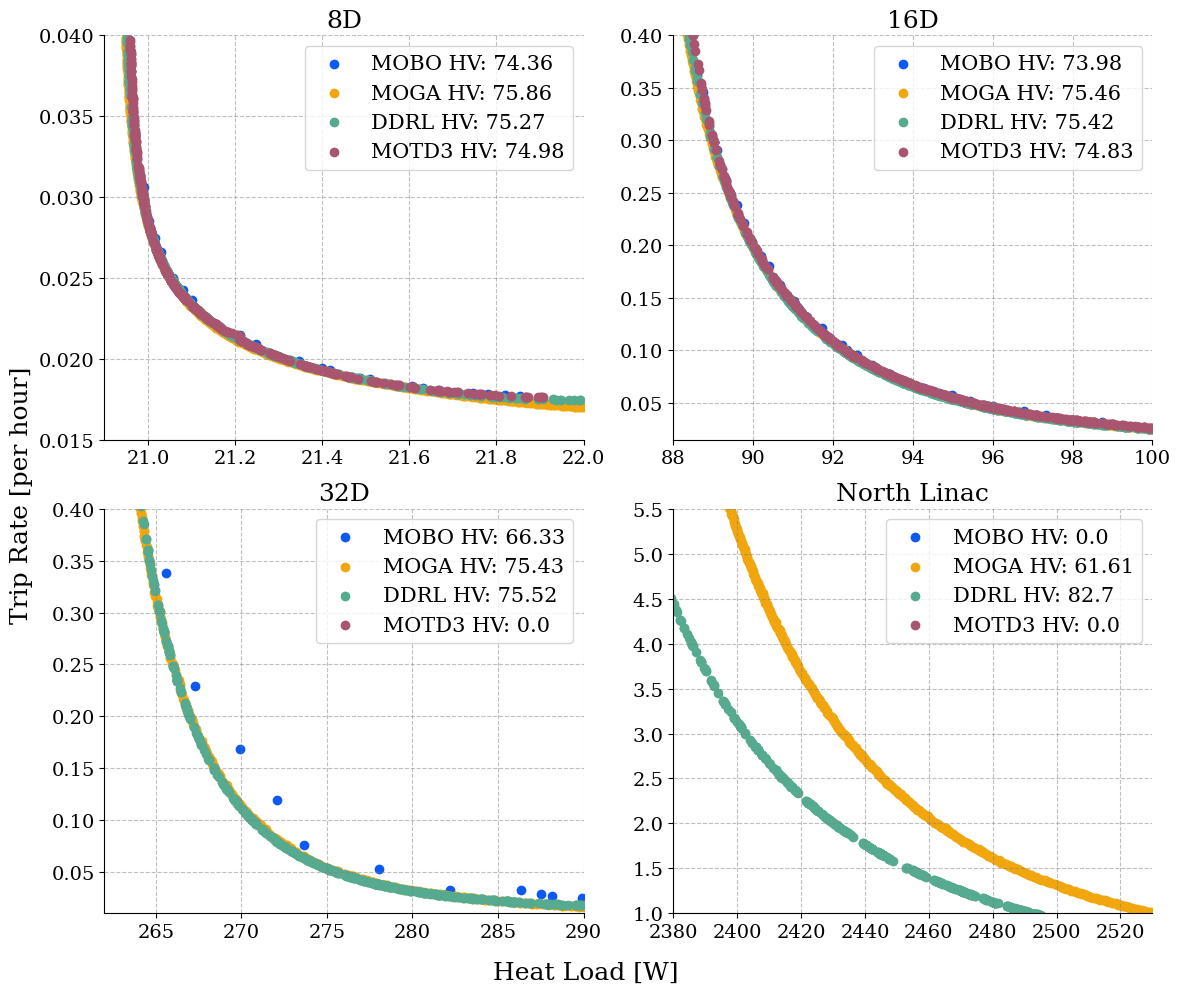

In [28]:
refs[0] = [22.0, 0.04]
get_pareto_comparison(results, env_list, algo_list, ideals, refs, saveloc="Best_Pareto_Comparison.pdf")

In [29]:
def get_pareto_comparison_alphaDDRL(results, env_list, algo_list, ideals, refs, saveloc=None):
    algo = "DDRL"
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    counter = 0
    i = 0
    for problem_name in env_list:
        best_pareto_indices = np.where(results[problem_name][algo][3] == np.max(results[problem_name][algo][3]))
        ind0, ind1 = best_pareto_indices[0][0], best_pareto_indices[1][0]
        max_hv = np.round(np.max(results[problem_name][algo][3]), 2)
        heat = results[problem_name][algo][0][ind0][ind1]
        trip = results[problem_name][algo][1][ind0][ind1]
        alpha = results[problem_name][algo][4][ind0][ind1]
        alpha = alpha[:, 0]
        
        sc = axs[counter//2, counter%2].scatter(heat, trip, label=algo+" HV: "+str(max_hv), c=alpha, marker="o")
        fig.colorbar(sc, ax=axs[counter//2, counter%2])
        axs[counter//2, counter%2].set_title(problem_name, fontsize=18)
        axs[counter//2, counter%2].grid(color="gray", alpha=0.5, ls="--")
    
        # Remove box around the plot
        axs[counter//2, counter%2].spines['top'].set_visible(False)
        axs[counter//2, counter%2].spines['right'].set_visible(False)
        axs[counter//2, counter%2].legend(fontsize=15)
        axs[counter//2, counter%2].tick_params(axis='both', which='major', labelsize=14)
        # axs[counter//2, counter%2].set_xlim([ideals[counter][0], refs[counter][0]])
        # axs[counter//2, counter%2].set_ylim([ideals[counter][1], refs[counter][1]])
        
        counter += 1
        
    fig.supxlabel('Heat Load [W]', fontsize=18)
    fig.supylabel('Trip Rate [per hour]', fontsize=18)
    plt.tight_layout()
    if saveloc is not None:
        plt.savefig(saveloc, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

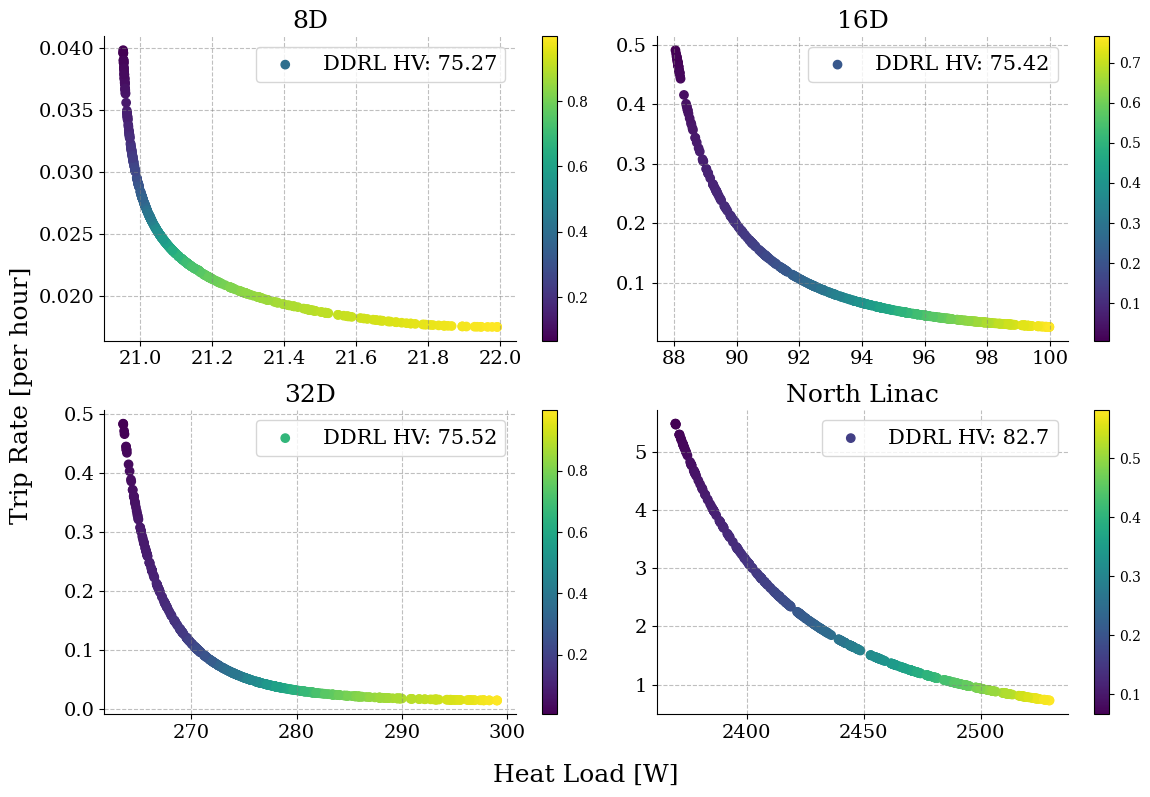

In [30]:
get_pareto_comparison_alphaDDRL(results, env_list, algo_list, ideals, refs, saveloc="DDRL_alpha.pdf")

In [31]:
def get_pareto_comparison_alphaMOTD3(results, env_list, algo_list, ideals, refs, saveloc=None):
    algo = "MOTD3"
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    counter = 0
    i = 0
    for problem_name in ["8D", "16D"]:
        best_pareto_indices = np.where(results[problem_name][algo][3] == np.max(results[problem_name][algo][3]))
        ind0, ind1 = best_pareto_indices[0][0], best_pareto_indices[1][0]
        max_hv = np.round(np.max(results[problem_name][algo][3]), 2)
        heat = results[problem_name][algo][0][ind0][ind1]
        trip = results[problem_name][algo][1][ind0][ind1]
        alpha = results[problem_name][algo][4][ind0][ind1]
        
        sc = axs[counter%2].scatter(heat, trip, label=algo+" HV: "+str(max_hv), c=alpha, marker="o")
        fig.colorbar(sc, ax=axs[counter%2])
        axs[counter%2].set_title(problem_name, fontsize=18)
        axs[counter%2].grid(color="gray", alpha=0.5, ls="--")
    
        # Remove box around the plot
        axs[counter%2].spines['top'].set_visible(False)
        axs[counter%2].spines['right'].set_visible(False)
        axs[counter%2].legend(fontsize=15)
        axs[counter%2].tick_params(axis='both', which='major', labelsize=14)
        
        counter += 1
        
    fig.supxlabel('Heat Load [W]', fontsize=18)
    fig.supylabel('Trip Rate [per hour]', fontsize=18)
    plt.tight_layout()
    if saveloc is not None:
        plt.savefig(saveloc, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

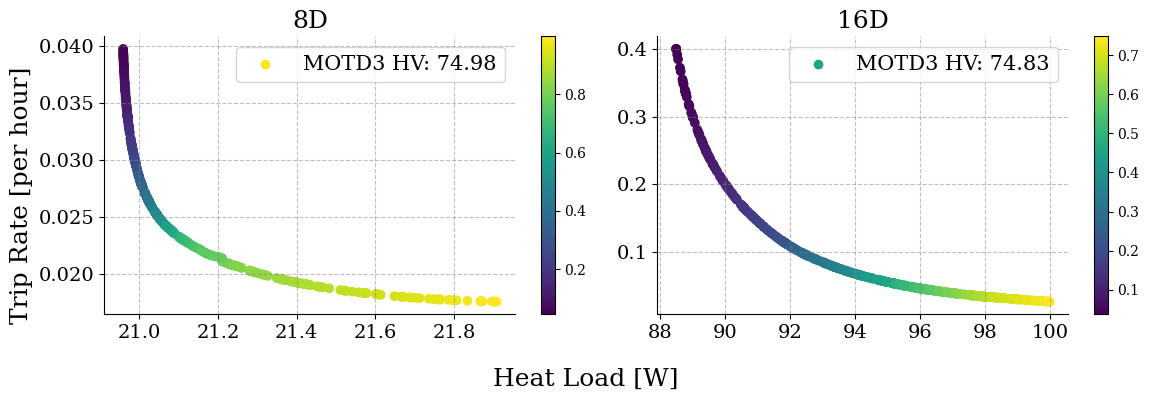

In [32]:
get_pareto_comparison_alphaMOTD3(results, env_list, algo_list, ideals, refs, saveloc="MOTD3_alpha.pdf")

MOBO 8D 47.234803777653475 8071.346247002409
MOBO 16D 109.062986594235 25762.030031127037
MOBO 32D 57.44289857170392 38469.6624991396
MOBO North Linac 4.8319102731027606 5238.76947913253


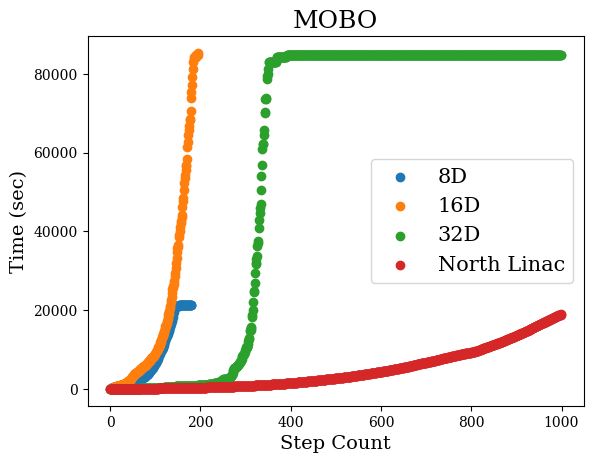

MOGA 8D 2.0031119931906147 574.1955554299229
MOGA 16D 2.0774096384703813 596.4023584450127
MOGA 32D 2.1272854031983384 611.0708585055678
MOGA North Linac 2.639619139984317 758.8484865050013


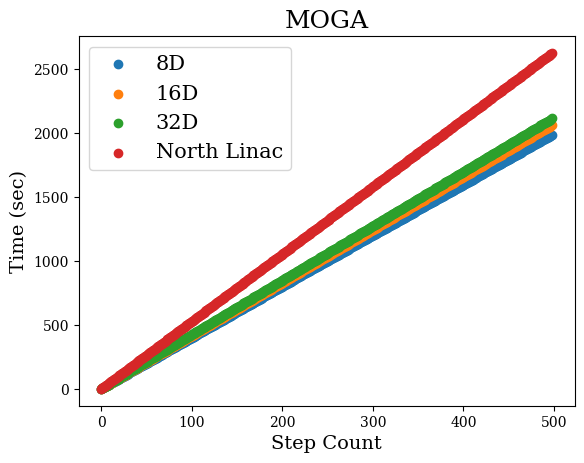

DDRL 8D 1.6023590733928679 460.19475711772077
DDRL 16D 1.637629538599968 472.0003421345778
DDRL 32D 1.6436903640813825 473.62895229186745
DDRL North Linac 2.226006384160042 635.9407815891141


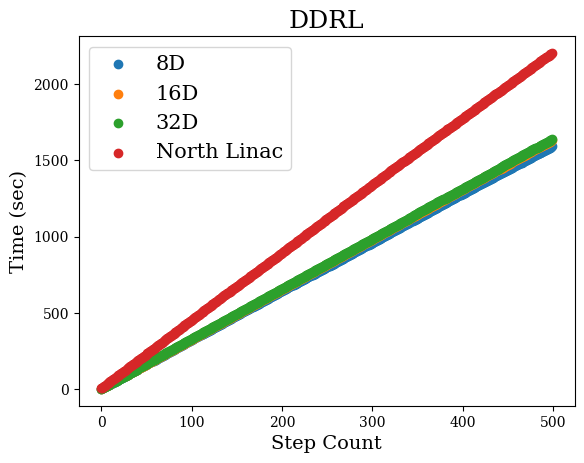

MOTD3 8D 1.9530903301661016 1154.2064944828041
MOTD3 16D 1.8223633410782814 1083.4901622560094
MOTD3 32D 1.850484160556793 1096.7784487513525
MOTD3 North Linac 5.581590584900618 3257.51297129537


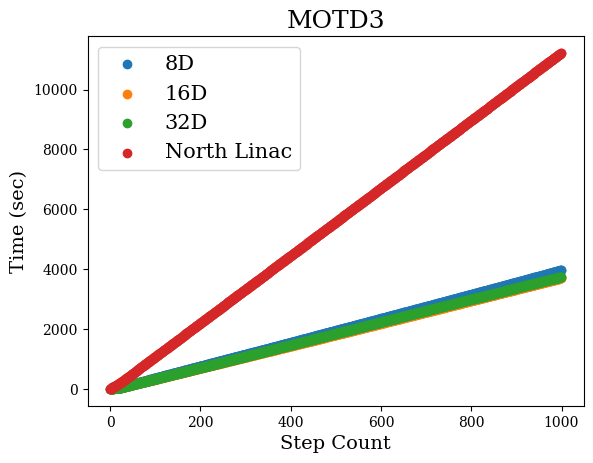

In [33]:
q_lower, q_higher = two_sigma_bound[0], two_sigma_bound[1]
for algo in algo_list:
    fig = plt.figure()
    for problem_name in env_list:
        time = np.median(results[problem_name][algo][2], axis=0)
        print(algo, problem_name, np.mean(time/time.shape[0]), np.std(time))
        q_low = np.quantile(results[problem_name][algo][2], axis=0, q=q_lower)
        q_high = np.quantile(results[problem_name][algo][2], axis=0, q=q_higher)
        plt.scatter(np.arange(time.shape[0]), time, label=problem_name)
        
    plt.legend(fontsize=15)
    plt.xlabel("Step Count", fontsize=14)
    plt.ylabel("Time (sec)", fontsize=14)
    plt.title(algo, fontsize=18)
    plt.show()
    
    

In [34]:
global_max = {}
for problem_name in ["8D", "16D", "32D"]:
    # for i in range(len(results[problem_name]['MOBO'][3])):
    print(np.max(results[problem_name]['MOBO'][3]))
    global_max[problem_name] = np.max(results[problem_name]['MOBO'][3])

74.36
73.985
66.33


In [35]:
time = {}
for algo in algo_list:
    time[algo] = {}
    for problem_name in env_list:
        time[algo][problem_name] = []
        for i in range(len(results[problem_name][algo][3])):
            ind = np.where(results[problem_name][algo][3][i] == np.max(results[problem_name][algo][3][i]))[0][0]
            # if np.max(results[problem_name][algo][3][i]) != np.max(results[problem_name][algo][3]):
            #     continue
            # print(problem_name, "Time Taken: ", results[problem_name][algo][2][i][ind])
            # print(np.max(results[problem_name][algo][3][i]))
            time[algo][problem_name].append(results[problem_name][algo][2][i][ind])

145
144
143
139
149
151
154
138
138
147
138
142
154
141
180
188
173
184
190
187
190
184
181
177
193
188
195
171
185
182
406
449
366
327
345
335
540
340
391
0
346
331
432
308
334
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
387
497
482
385
497
291
392
405
498
459
480
492
429
404
477
251
277
473
334
438
198
353
404
445
490
200
429
245
267
286
484
497
467
355
158
380
422
394
378
324
307
479
335
491
410
494
497
487
465
495
481
428
426
466
491
331
402
456
469
498
441
472
376
346
383
441
370
332
436
432
239
308
435
303
445
200
223
230
464
237
310
473
451
412
355
466
284
225
234
211
140
167
320
473
428
456
402
365
434
264
387
478
209
456
167
166
242
206
154
179
241
189
206
243
178
182
136
193
182
232
983
997
998
88
995
993
944
999
986
995
685
963
987
915
956
976
986
819
935
957
867
895
912
876
925
991
950
980
977
983
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [36]:
# algo = "DDRL"
# for problem_name in env_list:
#     for i in range(0, 15):
#         print(i)
#         ind = np.where(results[problem_name][algo][3][i] == np.max(results[problem_name][algo][3][i]))
#         print(results[problem_name][algo][2][i][ind[0]]+1000)

In [37]:
# time['MOBO']['8D']

MOBO 8D
21040.09756731987 20193.126986837386 21379.13564529419
MOBO 16D
84714.16951155663 80585.01078653336 85975.0611363411
MOBO 32D
MOBO North Linac
MOGA 8D
1911.0251417160034 1549.4408156871796 2023.1965349197387
MOGA 16D
1381.7658369541168 905.7449024677277 1900.716553544998
MOGA 32D
1675.4247329235077 1356.761208152771 2070.0971464157105
MOGA North Linac
2469.761631011963 2186.242868900299 2609.6483471870424
DDRL 8D
1253.1495456695557 967.9710758209228 1416.6809268951415
DDRL 16D
940.2939386367798 707.7214270114898 1510.9332666873931
DDRL 32D
1286.3589890003204 549.0542733192444 1522.6217128753663
DDRL North Linac
856.2273147106171 711.3119260311126 1067.362150287628
MOTD3 8D
3887.5570323467255 3042.8890109539034 3966.076670408249
MOTD3 16D
3512.3290722370148 3211.234408378601 3659.779214811325
MOTD3 32D
MOTD3 North Linac


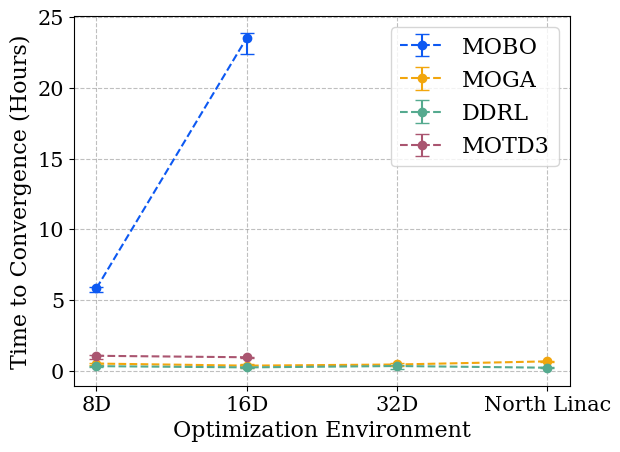

In [38]:
q_lower, q_upper = 0.1, 0.9
fig = plt.figure()
counter = 0
for algo in algo_list:
    res_list = []
    q1, q2 = [], []
    x_arr = []
    for problem_name in list(time[algo].keys()):
        print(algo, problem_name)
        if algo in ["MOTD3", "MOBO"] and problem_name in ["32D", "North Linac"]:
            continue
        res_list.append(np.median(time[algo][problem_name], axis=0))
        x_arr.append(problem_name)
        q1.append(np.quantile(time[algo][problem_name], axis=0, q=q_lower))
        q2.append(np.quantile(time[algo][problem_name], axis=0, q=q_upper))
        print(res_list[-1], q1[-1], q2[-1])
    res_list = np.array(res_list)
    q1 = np.array(q1)
    q2 = np.array(q2)
    plt.errorbar(x_arr, res_list/3600., yerr=np.stack([res_list-q1, q2-res_list])/3600., label=algo, color=colors[counter], fmt='o', capsize=5, ls="--")
    counter += 1
    
plt.ylabel("Time to Convergence (Hours)", fontsize=16)
plt.xlabel("Optimization Environment", fontsize=16)
plt.legend(fontsize=16)
plt.grid(ls="--", color="gray", alpha=0.5)
# plt.yscale("log")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig("convergence_time.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()